In [1]:
import matplotlib
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
import numpy as np
plots.style.use('fivethirtyeight')

## The SD and Bell Shaped Curves

Review: In a normal distribution, the first standard deviation can be visibly detected by approximating where the point of inflection of the curve is. The standard deviation tells you the distance from the mean (both positive and negative) to move to capture a certain percentage of the data. In general, about 68% of the data is within one standard deviation, 95% is within two, and 99.7% is within three. 

In [2]:
births = Table.read_table('baby.csv')

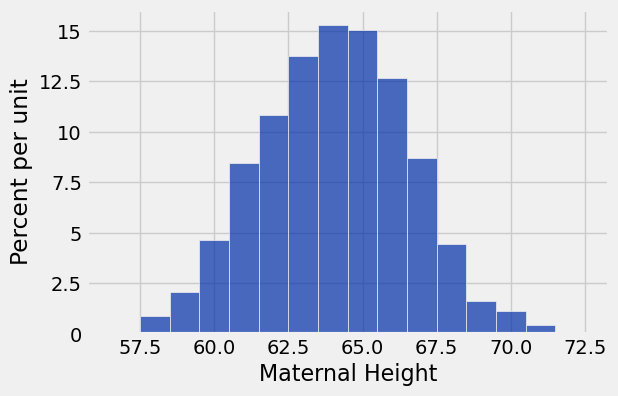

In [3]:
births.hist('Maternal Height', bins = np.arange(56.5, 72.6, 1))

In [4]:
heights = births.column('Maternal Height')
np.mean(heights), np.std(heights)

(64.049403747870528, 2.5250254409674375)

In [5]:
# COMPLETE the First Standard Dev: Find the low value and the high value of the first standard deviation 
# and display both.

low = np.mean(heights) - np.std(heights)
high = np.mean(heights) + np.std(heights)
low, high

(61.524378306903088, 66.574429188837968)

## Central Limit Theorem ##

The CLT says, that if we take the mean of many samples with a sample size of $n\geq30$, the distribution of the means will be normal regardless of what the original distribution was. 

In [6]:
united = Table.read_table('united.csv')
united_bins = np.arange(-20, 300, 10)
united

Date,Flight Number,Destination,Delay
6/1/15,73,HNL,257
6/1/15,217,EWR,28
6/1/15,237,STL,-3
6/1/15,250,SAN,0
6/1/15,267,PHL,64
6/1/15,273,SEA,-6
6/1/15,278,SEA,-8
6/1/15,292,EWR,12
6/1/15,300,HNL,20
6/1/15,317,IND,-10


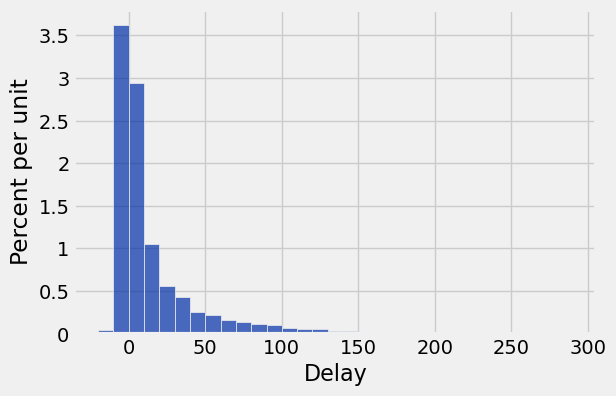

In [7]:
united.hist('Delay', bins=united_bins)

In [8]:
# COMPLETE: Find the mean and standard deviation of the delays using the numpy package commands.
delays = united.column('Delay')

delay_mean = np.mean(delays)
delay_sd = np.std(delays)

delay_mean, delay_sd

(16.658155515370705, 39.480199851609314)

In [9]:
# COMPLETE: Find the median of the delays

percentile(50, delays)

2

In [10]:
# COMPLETE: Create a function that creates a sample from the population of flights named sampled_flights
# and returns its mean based on the Delay.
def one_sample_mean(sample_size):
   
    sampled_flights = united.sample(sample_size).column('Delay')
    return np.mean(sampled_flights)

In [11]:
# Run the newly created function with a sample of 100

one_sample_mean(100)

20.02

In [12]:
# COMPLETE: Create a function that runs 10000 iterations of creating a sample and return the mean.
# store those results in an array named means. 
def ten_thousand_sample_means(sample_size):
    means = make_array()
    for i in np.arange(10000):
        means = np.append(means, one_sample_mean(sample_size))
    
    return means

In [13]:
# COMPLETE: Run the new function for a sample of size 100 assigning the output to 
# sample_means_100 and display the result.
sample_means_100 = ten_thousand_sample_means(100)
sample_means_100

array([ 20.92,  13.38,  23.33, ...,  11.76,  13.98,  14.71])

In [14]:
# COMPELTE: Confirm that there are 10000 entries in the sample_means_100 array.

len(sample_means_100)

10000

Population Average: 16.6581555154


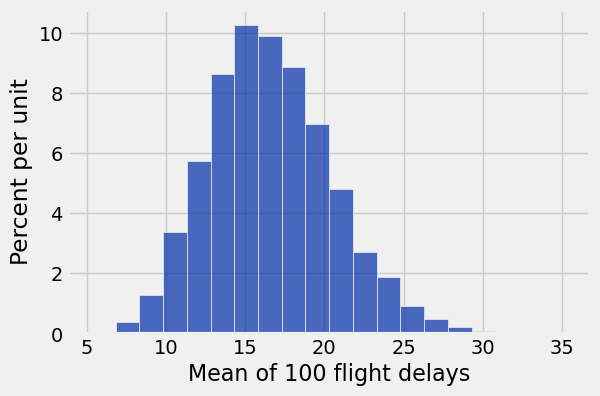

In [15]:
# QUESTION: What sample size and number of iterations will the histogram display?

Table().with_column(
    'Mean of 100 flight delays', sample_means_100).hist(bins=20)

print('Population Average:', delay_mean)

Population Average: 16.6581555154


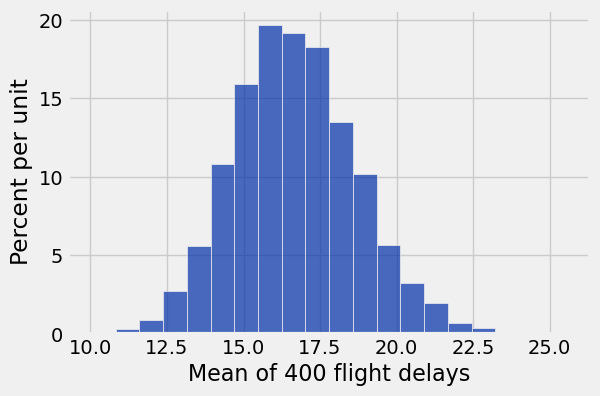

In [16]:
# QUESTION: What sample size and number of iterations will the histogram display?

sample_means_400 = ten_thousand_sample_means(400)
Table().with_column(
    'Mean of 400 flight delays', sample_means_400).hist(bins=20)

print('Population Average:', delay_mean)

***ANSWER: Why is the histogram curve close to normal?***



## Discussion Question
After rolling 1,000,000 fair 6-sided dice, which of these histograms would you expect to have a bell shape? Select all that apply. List what each histogram will look like in the cell below. 

1) The histogram of outcomes of these million rolls ...
2) The histogram that results from computing the average outcome of these million rolls ...
3) The histogram that results from splitting the outcomes into 1,000 groups of 1,000 (in the order they occurred) and computing the average outcome of each group ...